In [ ]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq

In [2]:
from typing import TypedDict

In [3]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [27]:
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
def get_groq_llm():
    return ChatOpenAI(
        model = "openai/gpt-oss-120b",
        base_url="https://api.groq.com/openai/v1",
        api_key = os.getenv("GROQ_API_KEY"),
        temperature = 0.7,
        max_tokens = 1000
    )

In [28]:
llm = get_groq_llm()

In [6]:
llm.invoke("Hi, how are you")

AIMessage(content="Hello! I'm doing great, thank you for asking. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 76, 'total_tokens': 127, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 24, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.052786482, 'prompt_time': 0.003239857, 'completion_time': 0.1067429, 'total_time': 0.109982757}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'id': 'chatcmpl-4207a418-a7a5-4ed9-8a71-0f993884e2f2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ddce0-bc56-7383-bae8-cad718dcaaae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 51, 'total_tokens': 127, 'input_token_details': {}, 'output_token_details': {'reasoning': 24}})

In [7]:
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
def get_groq_llm():
    return ChatOpenAI(
        model = "qwen/qwen3-32b",
        base_url="https://api.groq.com/openai/v1",
        api_key = os.getenv("GROQ_API_KEY"),
        temperature = 0.7,
        max_tokens = 1000
    )

In [13]:
llm2 = get_groq_llm()

In [11]:
llm2 = get_groq_llm()
response = llm2.invoke("how is agenticai and agents are different?")

In [12]:
print(response)

content='**Short answer:**  \n*“Agentic\u202fAI”* is a *design philosophy* and a *type of system* that is built to act with its own *purpose, goals, and self‑directed decision‑making*—in other words, it tries to exhibit **agency**.  \n*“Agents”* (or *software agents*) are the *building‑block abstraction* used in many AI and computer‑science fields. An agent is simply *any entity that perceives its environment, reasons about it, and takes actions*. Agents can be very lightweight (a single function that reacts to a message) or part of a large multi‑agent system, and they do **not** have to be “agentic” in the sense of having their own overarching purpose or autonomy.\n\nBelow is a more detailed comparison that shows where the two ideas overlap and where they diverge.\n\n---\n\n## 1. Core definitions  \n\n| Concept | What it means | Typical scope | Key properties |\n|---------|----------------|----------------|----------------|\n| **Agentic\u202fAI** | An AI system explicitly engineered t

## Creating Nodes and Edges in LangGraph

### 1.start and end nodes will come by default
### 2.Creating function for chat node.
### 3.In LangGraph every node id a function.

In [29]:
# LLMState inhereting TypedDict class
class LLMState(TypedDict):
    question:str
    answer:str

In [30]:
# Chat node
def chat_llm(state:LLMState):
    question = state["question"]
    # Prompt
    prompt = f"Answer the following question {question}"

    output_answer = llm.invoke(prompt).content
    state['answer'] = output_answer
    return state

In [31]:
# Creating Workflow in LangGraph
graph = StateGraph(LLMState)

# Adding Nodes
graph.add_node('chat LLM Node', chat_llm)

# Note:- Start and End node will be added by default by the LangGraph

In [32]:
# Adding Edges to the graph
# Adding Edge from START to chat LLM Node
graph.add_edge(START, 'chat LLM Node')
# Adding Edge From chatLLM Node to END
graph.add_edge('chat LLM Node', END)

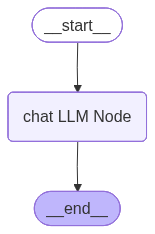

In [33]:
# Compliation of graph
workflow = graph.compile()
workflow

In [35]:
initial_question = {"question" : "What is the distance of moon from earth?"}

final_state = workflow.invoke(initial_question)
print(final_state)

{'question': 'What is the distance of moon from earth?', 'answer': 'The Moon orbits Earth at an average distance of **about\u202f384\u202f400\u202fkilometers (≈238\u202f900\u202fmiles)**.\n\n- **Closest point (perigee):** roughly 363\u202f300\u202fkm (≈225\u202f600\u202fmi)  \n- **Farthest point (apogee):** roughly 405\u202f500\u202fkm (≈251\u202f900\u202fmi)\n\nThese values are averages because the Moon’s orbit is slightly elliptical and its distance varies slightly over time.'}


In [37]:
print(final_state["answer"])

The Moon orbits Earth at an average distance of **about 384 400 kilometers (≈238 900 miles)**.

- **Closest point (perigee):** roughly 363 300 km (≈225 600 mi)  
- **Farthest point (apogee):** roughly 405 500 km (≈251 900 mi)

These values are averages because the Moon’s orbit is slightly elliptical and its distance varies slightly over time.


In [ ]:
# Asking second question
# Here we are asking a follow up question:- how far sun is from moon,
# Here the chat node dont have any kind of memory, so it cant answer follow up questions
initial_question = {"question" : "okay great but how far from sun?"}

final_state = workflow.invoke(initial_question)
print(final_state)

{'question': 'okay great but how far from sun?', 'answer': 'The average distance from Earth to the Sun is **about 1 astronomical unit (AU)**, which is:\n\n- **≈\u202f149.6\u202fmillion kilometres** (≈\u202f92.96\u202fmillion miles)  \n\nBecause Earth’s orbit is slightly elliptical, the distance varies over the year:\n\n| Orbital point | Distance from Sun |\n|---------------|-------------------|\n| **Perihelion** (closest, early\u202fJanuary) | ≈\u202f147.1\u202fmillion\u202fkm (≈\u202f91.4\u202fmillion\u202fmi) |\n| **Aphelion** (farthest, early\u202fJuly) | ≈\u202f152.1\u202fmillion\u202fkm (≈\u202f94.5\u202fmillion\u202fmi) |\n\nSo, on average, we’re roughly **150\u202fmillion kilometres** away from the Sun. If you need the distance for another planet or a specific spacecraft, just let me know!'}


In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)

In [4]:
llm.invoke("Hi")

AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={'reasoning_content': 'Okay, the user said "Hi". That\'s pretty open-ended. I should respond in a friendly and welcoming way. Maybe ask how I can assist them. Keep it simple and let them know I\'m here to help with whatever they need. Make sure the tone is positive and approachable.\n'}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 9, 'total_tokens': 84, 'completion_time': 0.144272461, 'completion_tokens_details': {'reasoning_tokens': 59}, 'prompt_time': 0.000224337, 'prompt_tokens_details': None, 'queue_time': 0.052788508, 'total_time': 0.144496798}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dd278-0a28-7b22-a036-e7b77fbfccf8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 75, 'total_tokens': 8